# Mathematical Accuracy Analysis

When we sum the total death counts from each parish (by plague and by all causes), how does that compare to the sum of the four subtotals calculated in the 17th/18th centuries and recorded in the Bills of Mortality? In other words, how accurate was the contemporary mathematics of the bills?

This version of the code uses data processed to exclude data marked illegible by transcribers but not duplicates.

# Fetch our data from Github

In [1]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv

--2025-11-18 19:21:03--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134914788 (129M) [text/plain]
Saving to: ‘all_bills.csv’

all_bills.csv       100%[===================>] 128.66M   261MB/s    in 0.5s    

2025-11-18 19:21:04 (261 MB/s) - ‘all_bills.csv’ saved [134914788/134914788]



In [2]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv

--2025-11-18 19:21:04--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 512969 (501K) [text/plain]
Saving to: ‘weeks.csv’

weeks.csv           100%[===================>] 500.95K  --.-KB/s    in 0.04s   

2025-11-18 19:21:04 (12.8 MB/s) - ‘weeks.csv’ saved [512969/512969]



In [3]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv

--2025-11-18 19:21:04--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10851 (11K) [text/plain]
Saving to: ‘parishes.csv’

parishes.csv        100%[===================>]  10.60K  --.-KB/s    in 0.001s  

2025-11-18 19:21:04 (20.7 MB/s) - ‘parishes.csv’ saved [10851/10851]



In [4]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv

--2025-11-18 19:21:04--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/subtotals.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8584383 (8.2M) [text/plain]
Saving to: ‘subtotals.csv’

subtotals.csv       100%[===================>]   8.19M  --.-KB/s    in 0.09s   

2025-11-18 19:21:04 (92.3 MB/s) - ‘subtotals.csv’ saved [8584383/8584383]



# Prepare the libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict

# Configure plotting
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 8)
warnings.filterwarnings('ignore')

# Load and remove illegible bills data

In [6]:
# Read in the all_bills.csv and weeks.csv files
all_bills = pd.read_csv(Path('all_bills.csv'))
weeks = pd.read_csv(Path('weeks.csv'))

# Merge the two dataframes on 'joinid', bringing in only selected columns from weeks
bills = all_bills.merge(
    weeks[['joinid', 'start_day', 'end_day', 'start_month', 'end_month','week_number']],
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
bills['start_day'] = bills['start_day'].astype('Int64')
bills['end_day'] = bills['end_day'].astype('Int64')

# Join the parish IDs
parishes = pd.read_csv(Path('parishes.csv'))
bills = bills.merge(parishes, left_on='parish_id', right_on='id', how='left')

# remove general bills by removing all bills with 'week_number' > 55
bills = bills[bills['week_number'] <= 55]

# remove Westminster pesthouse counts, which are not included in bills' subotals
bills = bills[bills['parish_id'] != 19]

# return head() for bills, sorted by year
bills.sort_values('year').head(10)

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number,id,parish_name,canonical_name,bills_subunit
247926,3,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,3,Alhallows Great,All Hallows the Great,97 parishes within the walls
247925,3,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,3,Alhallows Great,All Hallows the Great,97 parishes within the walls
247924,2,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls
247923,2,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls
247951,35,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,35,St Austins Parish,St Austin,97 parishes within the walls
247952,35,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,35,St Austins Parish,St Austin,97 parishes within the walls
247953,36,buried,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,36,St Bartholomew Exchange,St Bartholomew Exchange,97 parishes within the walls
247954,36,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,36,St Bartholomew Exchange,St Bartholomew Exchange,97 parishes within the walls
247955,39,buried,1,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,39,St Bennet Fynck,St Benet Fink,97 parishes within the walls
247956,39,plague,0,1635,1635112616351203,weekly,True,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50,39,St Bennet Fynck,St Benet Fink,97 parishes within the walls


Many of the bills have legibility issues, especially the 18th century bills which the team accessed via 40-year-old microfiche. We create a variant version of the bills dataframe containing only weeks with entirely legible data, for comparative analysis.

In [7]:
# Create a separate data frame that can hold data with illegible data removed.
# print the number of unique weeks in bills_legible
print(f"Total number of unique weeks in bills: {len(bills['joinid'].unique())}")

# Identify the unique weekly bills with illegible data in the bills data frame
bills_illegible = bills[bills['illegible'] == True]
bills_illegible.head()
illegible_bills_weeks = bills_illegible['joinid'].unique()

print(f"Total number of illegible weeks: {len(illegible_bills_weeks)}")
print(f"First 10 illegible weeks: {illegible_bills_weeks[:10]}")

# filter out all rows with a joinid from illegible_bills_weeks
bills_legible = bills[~bills['joinid'].isin(illegible_bills_weeks)]

# print the number of unique weeks in bills_legible
print(f"Total number of unique weeks in bills_legible: {len(bills_legible['joinid'].unique())}")


Total number of unique weeks in bills: 5219
Total number of illegible weeks: 1061
First 10 illegible weeks: [1662010616620113 1662011316620120 1662012016620127 1662012716620203
 1662022416620303 1662030316620310 1663122216631229 1663061616630623
 1663070716630714 1663080416630811]
Total number of unique weeks in bills_legible: 4158


# How many total weeks are in the dataset?

We want to know, first, how many weeks are in our entire dataset. Since weeks.csv includes all unique values for week ranges derived from our transcriptions, we can count how many weeks are available.

In [8]:
#print the total number of "weeks", including annual bills
num_unique_weeks = len(weeks)
print(f"Total number of unique weeks: {num_unique_weeks}")

#print the number of unique joinid in weeks
print(f"Total number of unique joinid in weeks: {weeks['joinid'].nunique()}")

#print the number of unique joinid in bills
print(f"Total number of unique joinid in bills: {bills['joinid'].nunique()}")

#identify joinid in weeks but not in bills
diff = set(weeks['joinid']) - set(bills['joinid'])

#print lenght of diff
print(f"Number of joinid in bills but not in weeks: {len(diff)}")

# print number of joinid in bills but not in weeks
# print(f"Joinid in bills but not in weeks: {set(weeks['joinid']) - set(bills['joinid'])}")

Total number of unique weeks: 5515
Total number of unique joinid in weeks: 5465
Total number of unique joinid in bills: 5219
Number of joinid in bills but not in weeks: 246


# Load and remove illegible subtotals (within, without, out-parishes)

In [9]:
# We build the subtotals separately rather than handle in the notebook.
subtotals_df = pd.read_csv(Path('subtotals.csv'))

# Filter out christening data, which we are not using
subtotals_df = subtotals_df[(subtotals_df['count_type'] != 'christened')]
subtotals_df.sort_values('year').tail(10)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier
29608,Westminster,buried,69,1752,1752010117520804,weekly,False,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-34-recto
29609,Westminster,plague,0,1752,1752010117520804,weekly,True,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-34-recto
29611,Within the walls,buried,25,1752,1752010117520811,weekly,False,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29612,Within the walls,plague,0,1752,1752010117520811,weekly,True,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29614,Without the walls,buried,89,1752,1752010117520811,weekly,False,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29615,Without the walls,plague,0,1752,1752010117520811,weekly,True,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29617,Middlesex and Surrey,buried,165,1752,1752010117520811,weekly,False,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29618,Middlesex and Surrey,plague,0,1752,1752010117520811,weekly,True,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29620,Westminster,buried,71,1752,1752010117520811,weekly,False,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto
29621,Westminster,plague,0,1752,1752010117520811,weekly,True,False,2025-10-27-Laxton-combineddata-weeklybills-par...,Laxton-1752-35-recto


Many of the bills have legibility issues, especially the 18th century bills which the team accessed via 40-year-old microfiche. We create a variant version of the subtotal dataframe containing only weeks with entirely legible data, for comparative analysis.

In [10]:
# Identify the unique weekly bills with illegible data in subtotals_df
subtotals_illegible = subtotals_df[subtotals_df['illegible'] == True]
subtotals_illegible.head(10)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier
2056,Without the walls,buried,127,1691,1691111016911117,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1691-48-recto
2512,Without the walls,buried,107,1692,1692080216920809,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1692-34-recto
2788,Without the walls,buried,161,1693,1693011616930123,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1693-05-recto
3067,Middlesex and Surrey,buried,127,1693,1693070416930711,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1693-30-recto
3088,Without the walls,buried,122,1693,1693071816930725,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1693-32-recto
3356,Middlesex and Surrey,plague,0,1694,1694121816941225,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1694-01-recto
3490,Westminster,buried,92,1694,1694030516940312,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1694-12-recto
3836,Middlesex and Surrey,plague,0,1694,1694100916941016,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1694-43-recto
4435,Middlesex and Surrey,buried,98,1695,1695091716950924,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1695-40-recto
4447,Middlesex and Surrey,buried,81,1695,1695092416951001,weekly,False,True,2025-10-27-BLV4-combineddata-weeklybills-paris...,BL-1695-41-recto


In [11]:
illegible_subtotal_weeks = subtotals_illegible['joinid'].unique()

# Filter out all weekly bills that contain one or more illegible subtotals
subtotals_legible = subtotals_df[~subtotals_df['joinid'].isin(illegible_subtotal_weeks)]

# Print results
print(f"Total number of unique weeks in subtotals_df: {len(subtotals_df['joinid'].unique())}")
print(f"Total number of illegible weeks: {len(illegible_subtotal_weeks)}")
print(f"First 10 illegible weeks: {illegible_subtotal_weeks[:10]}")
print(f"Total number of unique weeks in subtotals_legible: {len(subtotals_legible['joinid'].unique())}")

Total number of unique weeks in subtotals_df: 5219
Total number of illegible weeks: 200
First 10 illegible weeks: [1691111016911117 1692080216920809 1693011616930123 1693070416930711
 1693071816930725 1694121816941225 1694030516940312 1694100916941016
 1695091716950924 1695092416951001]
Total number of unique weeks in subtotals_legible: 5019


# Cross-Check Removed Weeks

If a week has been removed from bills, it should also be removed from subtotals, and vice versa.

In [12]:
# Identify all joinid from bills_legible that are not in subtotals_legible
missing_subtotals = bills_legible[~bills_legible['joinid'].isin(subtotals_legible)]
missing_subtotals.head()

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number,id,parish_name,canonical_name,bills_subunit
0,24,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,24,St Alban Woodstreet,St Alban Wood Street,97 parishes within the walls
1,24,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,24,St Alban Woodstreet,St Alban Wood Street,97 parishes within the walls
2,1,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,1,Alhallows Barking,All Hallows Barking,97 parishes within the walls
3,1,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,1,Alhallows Barking,All Hallows Barking,97 parishes within the walls
4,2,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,16,23,December,December,1,2,Alhallows Breadstreet,All Hallows Bread Street,97 parishes within the walls


In [13]:
# print the number of rows in subtotals_legible
print(f"Total number of unique weeks in subtotals_legible: {len(subtotals_legible['joinid'].unique())}")

# print the number of rows in bills_legible
print(f"Total number of unique weeks in bills_legible: {len(bills_legible['joinid'].unique())}")

# print the number of rows in missing_subtotals
print(f"Total number of unique weeks in missing_subtotals: {len(missing_subtotals['joinid'].unique())}")

Total number of unique weeks in subtotals_legible: 5019
Total number of unique weeks in bills_legible: 4158
Total number of unique weeks in missing_subtotals: 4158


In [14]:
# # Identify all joinid from subtotals_legible that are not in bills_legible
# missing_bills = subtotals_legible[~subtotals_legible['joinid'].isin(bills_legible)]

# #print number of unique joinid in missing_bills
# print(f"Total number of unique weeks in missing_bills: {missing_bills['joinid'].nunique()}")

In [15]:
# Remove all joinid from subtotals_legible that are not in bills_legible
temporary = subtotals_legible[subtotals_legible['joinid'].isin(bills_legible['joinid'])]

# Remove all joinid from bills_legible that are not in subtotals_legible
bills_legible = bills_legible[bills_legible['joinid'].isin(subtotals_legible['joinid'])]

# print the number of rows in bills_legible
print(f"Total number of unique weeks in bills_legible: {len(bills_legible['joinid'].unique())}")

# print the number of rows in temporary
print(f"Total number of unique weeks in temporary: {len(temporary['joinid'].unique())}")

subtotals_legible = temporary #this workaround does not seem to have been needed but leaving it in for now

# print the number of rows in subtotals_legible
print(f"Total number of unique weeks in subtotals_legible: {len(subtotals_legible['joinid'].unique())}")



Total number of unique weeks in bills_legible: 4080
Total number of unique weeks in temporary: 4080
Total number of unique weeks in subtotals_legible: 4080


# Sum Parish Counts

We sum the count of our transcribed parish data for buried and plague values in order to compare against the subtotaled values in the bills.

In [16]:
# overwrite original bills and subtotals data frame with legible data

bills = bills_legible
subtotals_df = subtotals_legible

In [17]:
# Optionally filter
# bills = bills[bills['year'] == 1636]

# Create a list to hold our data
data_frames = []

# Process buried data
buried_data = bills[bills['count_type'] == 'buried']
buried_totals = buried_data.groupby(['year', 'week_number'])['count'].sum().reset_index()
buried_totals['count_type'] = 'buried'
data_frames.append(buried_totals)

# Process plague data
plague_data = bills[bills['count_type'] == 'plague']
plague_totals = plague_data.groupby(['year', 'week_number'])['count'].sum().reset_index()
plague_totals['count_type'] = 'plague'
data_frames.append(plague_totals)

# Combine all data
weekly_totals = pd.concat(data_frames, ignore_index=True)

# Sort by year, week_number and count_type for better readability
weekly_totals = weekly_totals.sort_values(['year', 'week_number', 'count_type'])

print("Combined weekly totals:")
print(f"Columns: {weekly_totals.columns.tolist()}")
print(f"Shape: {weekly_totals.shape}")
print(weekly_totals.head(10))

Combined weekly totals:
Columns: ['year', 'week_number', 'count', 'count_type']
Shape: (6283, 4)
      year  week_number  count count_type
0     1635           50    209     buried
4061  1635           50      0     plague
1     1636           20    206     buried
4062  1636           20      4     plague
2     1636           21    254     buried
4063  1636           21     41     plague
3     1636           22    244     buried
4064  1636           22     22     plague
4     1636           23    264     buried
4065  1636           23     39     plague


In [18]:
# Join the weeks to the subtotals
# Use weeks_df (the DataFrame read earlier) in case 'weeks' was overwritten as a list
if 'weeks_df' in globals():
    weeks_to_merge = weeks[['joinid', 'start_day', 'end_day', 'start_month', 'end_month', 'week_number']]
else:
    # fallback: reload weeks if needed
    weeks_to_merge = pd.read_csv(Path('weeks.csv'))[['joinid', 'start_day', 'end_day', 'start_month', 'end_month', 'week_number']]

# remove the christening data for now
subtotals = subtotals_df.merge(
    weeks_to_merge,
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
subtotals['start_day'] = subtotals['start_day'].astype('Int64')
subtotals['end_day'] = subtotals['end_day'].astype('Int64')

subtotals.sort_values('year').head(10)

,subtotal_category,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number
5698,Without the walls,buried,92,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
5697,Within the walls,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
5699,Without the walls,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
5700,Middlesex and Surrey,buried,65,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
5701,Middlesex and Surrey,plague,0,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
5696,Within the walls,buried,52,1635,1635112616351203,weekly,False,False,2023-05-30-HEH1635-weeklybills-parishes.csv,Huntington-1635-50-recto,26,3,November,December,50
29756,Within the walls,buried,77,1636,1636080416360811,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-34-recto,4,11,August,August,34
29757,Within the walls,plague,35,1636,1636080416360811,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-34-recto,4,11,August,August,34
29764,Without the walls,buried,428,1636,1636082516360901,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-37-recto,25,1,August,September,37
29765,Without the walls,plague,265,1636,1636082516360901,weekly,False,False,2025-11-01-BodleianV1-weeklybills-parishes.csv,Bodleian-1636-37-recto,25,1,August,September,37


# Data Comparisons

In [19]:
calculated = weekly_totals[['year', 'week_number', 'count_type', 'count']].copy()
calculated = calculated.rename(columns={'count': 'calculated_total'})

print("Created calculated:")
print(f"Columns: {calculated.columns.tolist()}")
print(f"Shape: {calculated.shape}")
print(calculated.head(10))

Created calculated:
Columns: ['year', 'week_number', 'count_type', 'calculated_total']
Shape: (6283, 4)
      year  week_number count_type  calculated_total
0     1635           50     buried               209
4061  1635           50     plague                 0
1     1636           20     buried               206
4062  1636           20     plague                 4
2     1636           21     buried               254
4063  1636           21     plague                41
3     1636           22     buried               244
4064  1636           22     plague                22
4     1636           23     buried               264
4065  1636           23     plague                39


In [20]:
# Sum the subtotals by year, week, and count_type
weekly_subtotals_sum = (
    subtotals
    .groupby(['year', 'week_number', 'count_type'], dropna=False)['count']
    .sum()
    .reset_index(name='subtotal_sum')
)

print("Created weekly_subtotals_sum:")
print(f"Columns: {weekly_subtotals_sum.columns.tolist()}")
print(f"Shape: {weekly_subtotals_sum.shape}")
print(weekly_subtotals_sum.head(10))

Created weekly_subtotals_sum:
Columns: ['year', 'week_number', 'count_type', 'subtotal_sum']
Shape: (8122, 4)
   year  week_number count_type  subtotal_sum
0  1635           50     buried           209
1  1635           50     plague             0
2  1636           20     buried           206
3  1636           20     plague             4
4  1636           21     buried           254
5  1636           21     plague            41
6  1636           22     buried           244
7  1636           22     plague            22
8  1636           23     buried           263
9  1636           23     plague            39


In [21]:
# Merge with calculated totals
comparison = weekly_subtotals_sum.merge(
    calculated,
    on=['year', 'week_number', 'count_type'],
    how='outer'
)

# Calculate differences
comparison['calculated_total'] = comparison['calculated_total'].fillna(0).astype(int)
comparison['subtotal_sum'] = comparison['subtotal_sum'].fillna(0).astype(int)
comparison['difference'] = comparison['subtotal_sum'] - comparison['calculated_total']
comparison['matches'] = comparison['difference'] == 0

# Sort by year, week, and count_type
comparison = comparison.sort_values(['year', 'week_number', 'count_type']).reset_index(drop=True)

# Restrict to weeks 1-55
comparison = comparison[(comparison['week_number'] >= 1) & (comparison['week_number'] <= 55)]

print(f"\nTotal comparisons: {len(comparison):,}; Exact matches: {comparison['matches'].sum():,} ({comparison['matches'].mean()*100:.1f}%)")
print("\nFirst 20 rows:")
comparison[['year', 'week_number', 'count_type', 'subtotal_sum', 'calculated_total', 'difference', 'matches']].head(20)


Total comparisons: 8,122; Exact matches: 7,273 (89.5%)

First 20 rows:


,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
0,1635,50,buried,209,209,0,True
1,1635,50,plague,0,0,0,True
2,1636,20,buried,206,206,0,True
3,1636,20,plague,4,4,0,True
4,1636,21,buried,254,254,0,True
5,1636,21,plague,41,41,0,True
6,1636,22,buried,244,244,0,True
7,1636,22,plague,22,22,0,True
8,1636,23,buried,263,264,-1,False
9,1636,23,plague,39,39,0,True


In [22]:
# Look at the calculated totals from 1700 afterward; just look at buried and plague, not christened
comparison_filtered_1700 = comparison[(comparison['year'] >= 1700) & (comparison['count_type'].isin(['buried', 'plague']))]
comparison_filtered_1700.head(20)

,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
4392,1700,14,buried,420,420,0,True
4393,1700,14,plague,0,0,0,True
4394,1700,15,buried,360,350,10,False
4395,1700,15,plague,0,0,0,True
4396,1700,16,buried,364,364,0,True
4397,1700,16,plague,0,0,0,True
4398,1700,17,buried,390,390,0,True
4399,1700,17,plague,0,0,0,True
4400,1700,18,buried,358,358,0,True
4401,1700,18,plague,0,0,0,True


In [23]:
# Create a new DataFrame filtering out rows where calculated_total is 0
comparison_filtered_zeros = comparison[comparison['calculated_total'] != 0].copy()

print("Comparison dataframe excluding weeks with zero calculated total:")
display(comparison_filtered_zeros.head())

Comparison dataframe excluding weeks with zero calculated total:


,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
0,1635,50,buried,209,209,0,True
2,1636,20,buried,206,206,0,True
3,1636,20,plague,4,4,0,True
4,1636,21,buried,254,254,0,True
5,1636,21,plague,41,41,0,True


# Summary Statistics

In [24]:
# Summary statistics
comparison_data_buried = comparison[comparison['count_type'] == "buried"]

perfect_matches = (comparison_data_buried['difference'] == 0).sum()
within_5 = (abs(comparison_data_buried['difference']) <= 5).sum()
within_10 = (abs(comparison_data_buried['difference']) <= 10).sum()
positive = (comparison_data_buried['difference'] > 0).sum()
negative = (comparison_data_buried['difference'] < 0).sum()

print(f"Statistics for buried data:\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data_buried)*100:.1f}%)\n"
      f"Within ±5: {within_5:,} ({within_5/len(comparison_data_buried)*100:.1f}%)\n"
      f"Within ±10: {within_10:,} ({within_10/len(comparison_data_buried)*100:.1f}%)\n"
      f"\n"
      f"Subtotal > Parish: {positive:,} ({positive/len(comparison_data_buried)*100:.1f}%)\n"
      f"Parish > Subtotal: {negative:,} ({negative/len(comparison_data_buried)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {comparison_data_buried['difference'].mean():+.1f}\n"
      f"Median difference: {comparison_data_buried['difference'].median():+.1f}\n"
      f"Std: {comparison_data_buried['difference'].std():.1f}\n"
      f"Range: {comparison_data_buried['difference'].min():+.1f} to {comparison_data_buried['difference'].max():+.1f}")

Statistics for buried data:
Perfect matches: 3,219 (79.3%)
Within ±5: 3,721 (91.6%)
Within ±10: 3,898 (96.0%)

Subtotal > Parish: 447 (11.0%)
Parish > Subtotal: 395 (9.7%)

Mean difference: -0.7
Median difference: +0.0
Std: 11.1
Range: -190.0 to +126.0


In [25]:
# Summary statistics for plague data
comparison_data_plague = comparison[comparison['count_type'] == "plague"]

perfect_matches = (comparison_data_plague['difference'] == 0).sum()
within_5 = (abs(comparison_data_plague['difference']) <= 5).sum()
within_10 = (abs(comparison_data_plague['difference']) <= 10).sum()
positive = (comparison_data_plague['difference'] > 0).sum()
negative = (comparison_data_plague['difference'] < 0).sum()

print(f"Statistics for plague data:\n"
      f"Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data_plague)*100:.1f}%)\n"
      f"Within ±5: {within_5:,} ({within_5/len(comparison_data_plague)*100:.1f}%)\n"
      f"Within ±10: {within_10:,} ({within_10/len(comparison_data_plague)*100:.1f}%)\n"
      f"\n"
      f"Subtotal > Parish: {positive:,} ({positive/len(comparison_data_plague)*100:.1f}%)\n"
      f"Parish > Subtotal: {negative:,} ({negative/len(comparison_data_plague)*100:.1f}%)\n"
      f"\n"
      f"Mean difference: {comparison_data_plague['difference'].mean():+.1f}\n"
      f"Median difference: {comparison_data_plague['difference'].median():+.1f}\n"
      f"Std: {comparison_data_plague['difference'].std():.1f}\n"
      f"Range: {comparison_data_plague['difference'].min():+.1f} to {comparison_data_plague['difference'].max():+.1f}")

Statistics for plague data:
Perfect matches: 4,054 (99.8%)
Within ±5: 4,060 (100.0%)
Within ±10: 4,060 (100.0%)

Subtotal > Parish: 5 (0.1%)
Parish > Subtotal: 2 (0.0%)

Mean difference: -0.0
Median difference: +0.0
Std: 0.3
Range: -20.0 to +5.0


# Visualizations

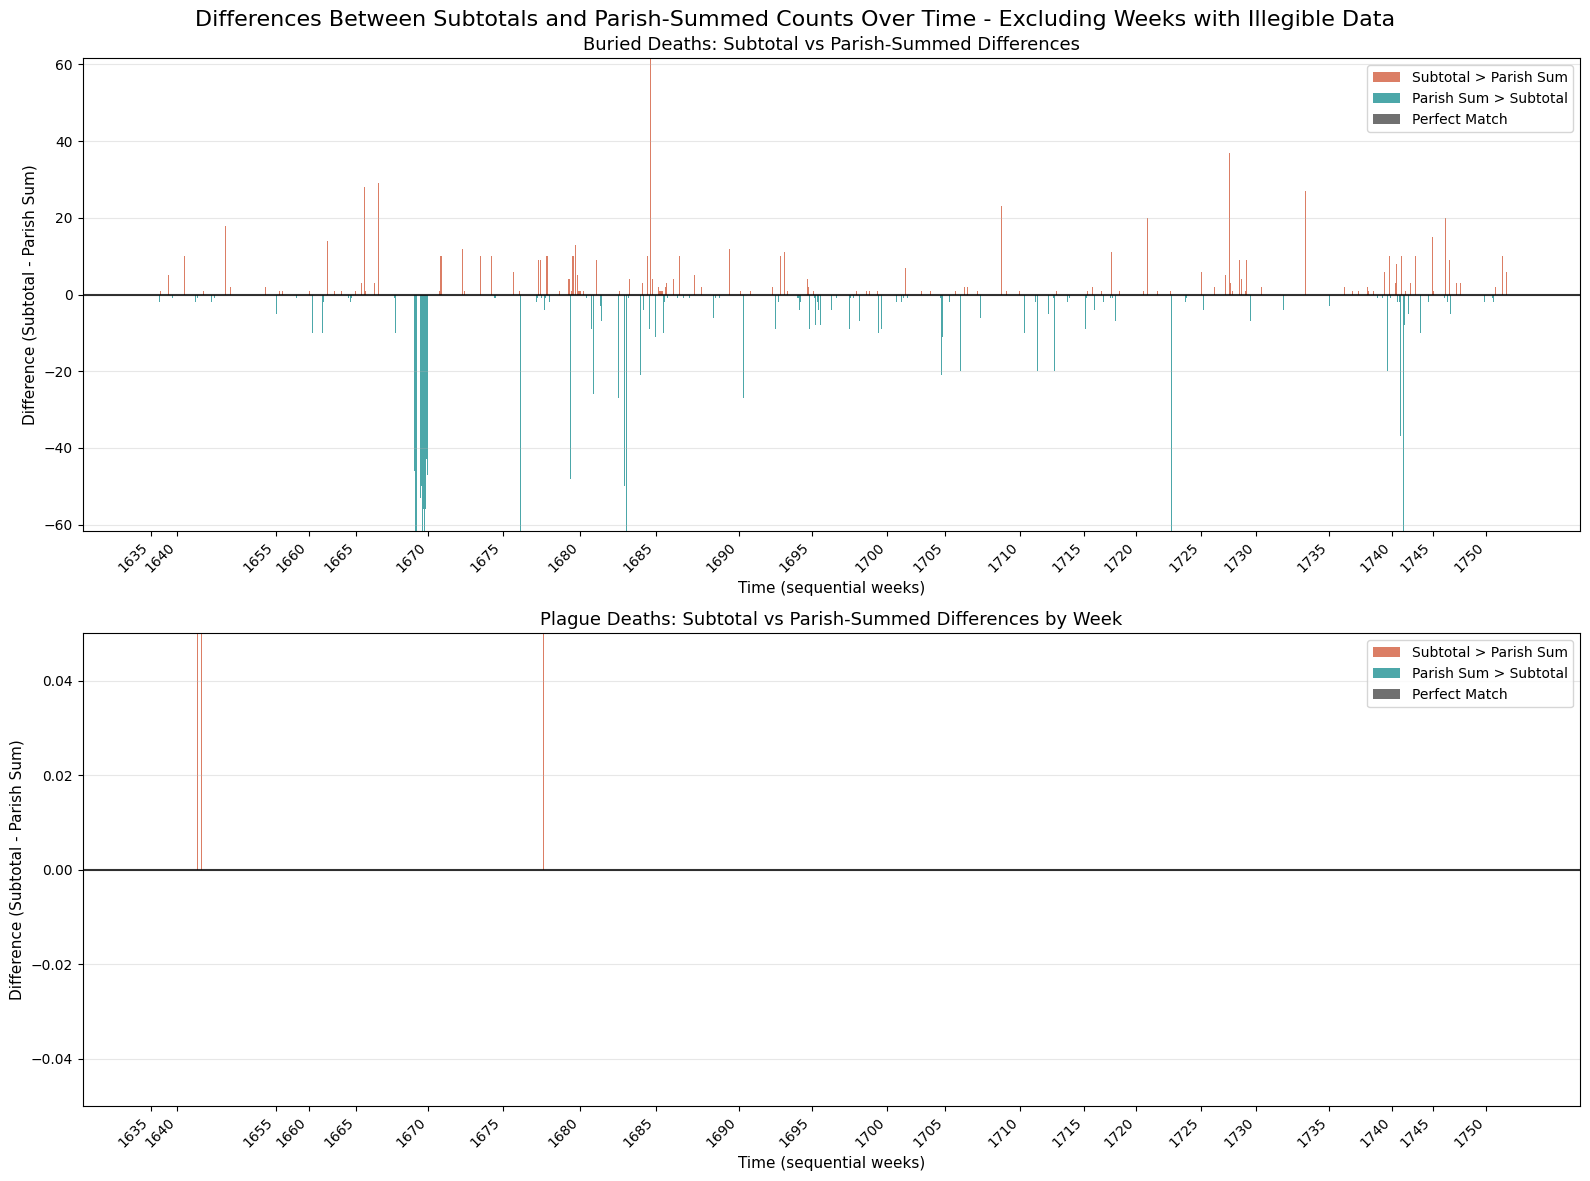

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Differences Between Subtotals and Parish-Summed Counts Over Time - Excluding Weeks with Illegible Data', fontsize=16, y=0.98)

count_types = ['buried', 'plague']
colors = ['#1f77b4', '#ff7f0e']
titles = ['Buried Deaths: Subtotal vs Parish-Summed Differences', 'Plague Deaths: Subtotal vs Parish-Summed Differences by Week']

for idx, count_type in enumerate(count_types):
    ax = ax1 if idx == 0 else ax2
    color = colors[idx]

    # Use 'comparison' dataframe
    comparison_data = comparison[comparison['count_type'] == count_type].copy()

    if len(comparison_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
        continue

    comparison_data = comparison_data.sort_values(['year', 'week_number']).reset_index(drop=True)
    comparison_data['time_index'] = range(len(comparison_data))

    # Color bars based on positive/negative
    colors_bars = ['#cc4824' if x > 0 else '#008285' if x < 0 else '#333333' for x in comparison_data['difference']]

    bars = ax.bar(comparison_data['time_index'], comparison_data['difference'], width=1.0, alpha=0.7, color=colors_bars)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Perfect Match (0)')

    ax.set_xlabel('Time (sequential weeks)', fontsize=11)
    ax.set_ylabel('Difference (Subtotal - Parish Sum)', fontsize=11)
    ax.set_title(titles[idx], fontsize=13)

    # Add legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#cc4824', alpha=0.7, label='Subtotal > Parish Sum'),
        Patch(facecolor='#008285', alpha=0.7, label='Parish Sum > Subtotal'),
        Patch(facecolor='#333333', alpha=0.7, label='Perfect Match')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    # Year markers - show every 5 years or adjust based on data range
    if len(comparison_data) > 0:
        year_positions = []
        year_labels = []
        current_year = None
        year_range = comparison_data['year'].max() - comparison_data['year'].min()
        year_step = 5 if year_range > 50 else 2  # Adjust step based on range

        for i, row in comparison_data.iterrows():
            if current_year is None or row['year'] != current_year:
                if current_year is None or int(row['year']) % year_step == 0:
                    year_positions.append(i)
                    year_labels.append(str(int(row['year'])))
                current_year = row['year']

        if year_positions:
            ax.set_xticks(year_positions)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

    # Set y-axis limits
    q1 = comparison_data['difference'].quantile(0.01)
    q99 = comparison_data['difference'].quantile(0.99)
    y_range = max(abs(q1), abs(q99))
    ax.set_ylim(-y_range * 1.1, y_range * 1.1)

plt.tight_layout()
plt.show()

We can examine our data by specific year ranges as well, by setting the `YEAR_START` and `YEAR_END` parameters.

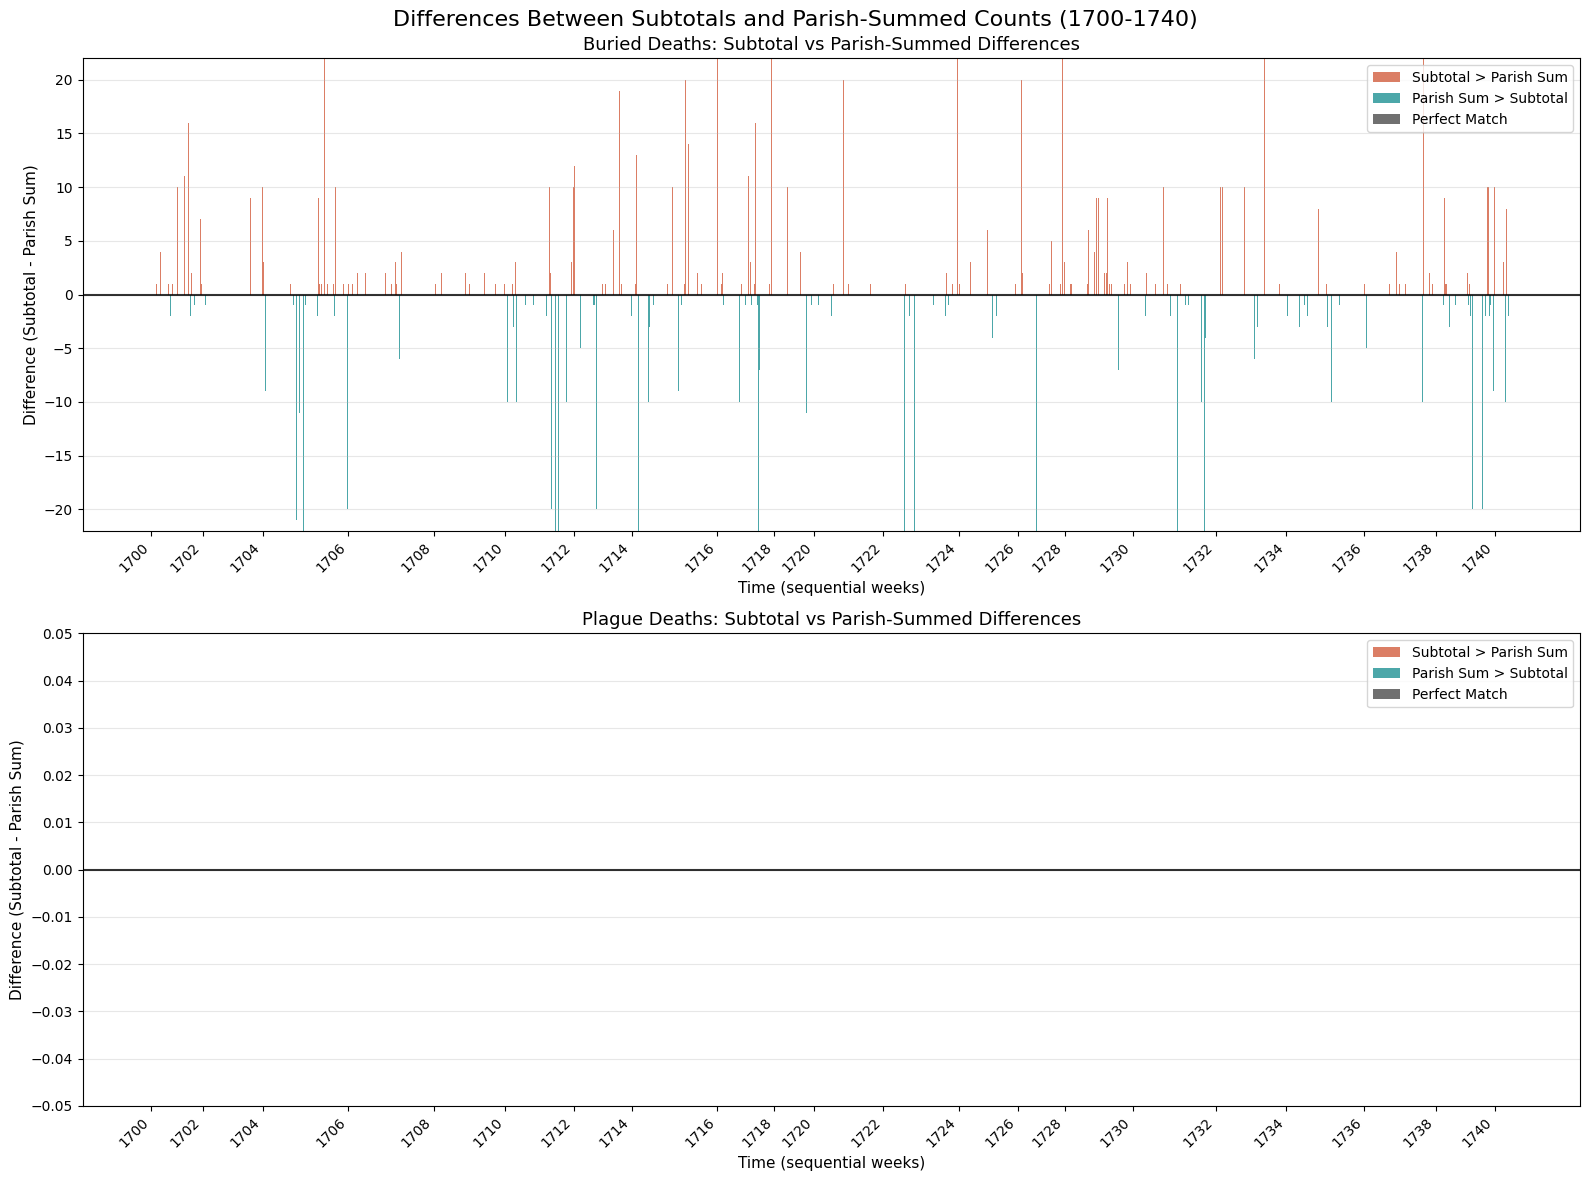

In [27]:
# === CONFIGURATION ===
YEAR_START = 1700
YEAR_END = 1740
USE_YEAR_FILTER = True  # Set to False to see all years

# === PLOTTING ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

if USE_YEAR_FILTER:
    fig.suptitle(f'Differences Between Subtotals and Parish-Summed Counts ({YEAR_START}-{YEAR_END})', fontsize=16, y=0.98)
else:
    fig.suptitle('Differences Between Subtotals and Parish-Summed Counts (All Years)', fontsize=16, y=0.98)

count_types = ['buried', 'plague']
titles = ['Buried Deaths: Subtotal vs Parish-Summed Differences', 'Plague Deaths: Subtotal vs Parish-Summed Differences']

for idx, count_type in enumerate(count_types):
    ax = ax1 if idx == 0 else ax2

    comparison_data = comparison[comparison['count_type'] == count_type].copy()

    # Apply year filter if enabled
    if USE_YEAR_FILTER:
        comparison_data = comparison_data[(comparison_data['year'] >= YEAR_START) & (comparison_data['year'] <= YEAR_END)]

    if len(comparison_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
        continue

    comparison_data = comparison_data.sort_values(['year', 'week_number']).reset_index(drop=True)

    # Color bars based on positive/negative
    colors_bars = ['#cc4824' if x > 0 else '#008285' if x < 0 else '#333333' for x in comparison_data['difference']]

    # Decide whether to use week numbers or sequential index based on year range
    year_range = YEAR_END - YEAR_START if USE_YEAR_FILTER else comparison_data['year'].max() - comparison_data['year'].min()

    if USE_YEAR_FILTER and year_range <= 2:
        # For 1-2 years, use week_number on x-axis
        if year_range <= 1:
            # Single year: just show week numbers
            x_values = comparison_data['week_number']
            ax.set_xlabel('Week Number', fontsize=11)
        else:
            # Multiple years: create combined year-week identifier
            comparison_data['year_week'] = comparison_data['year'].astype(str) + '-W' + comparison_data['week_number'].astype(int).astype(str)
            comparison_data['x_pos'] = range(len(comparison_data))
            x_values = comparison_data['x_pos']
            ax.set_xlabel('Week (Year-Week)', fontsize=11)

        bars = ax.bar(x_values, comparison_data['difference'], width=0.8, alpha=0.7, color=colors_bars)

        if year_range <= 1:
            # Show every 5th week for single year
            ax.set_xticks(range(0, int(comparison_data['week_number'].max()) + 1, 5))
        else:
            # Show year boundaries for multi-year
            year_positions = []
            year_labels = []
            current_year = None
            for i, row in comparison_data.iterrows():
                if row['year'] != current_year:
                    year_positions.append(row['x_pos'])
                    year_labels.append(f"{int(row['year'])}")
                    current_year = row['year']
            if year_positions:
                ax.set_xticks(year_positions)
                ax.set_xticklabels(year_labels, rotation=0)
    else:
        # For many years, use sequential time index
        comparison_data['time_index'] = range(len(comparison_data))
        bars = ax.bar(comparison_data['time_index'], comparison_data['difference'], width=1.0, alpha=0.7, color=colors_bars)
        ax.set_xlabel('Time (sequential weeks)', fontsize=11)

        # Year markers - show every 5 years or adjust based on data range
        year_positions = []
        year_labels = []
        current_year = None
        year_step = 5 if year_range > 50 else 2  # Adjust step based on range

        for i, row in comparison_data.iterrows():
            if current_year is None or row['year'] != current_year:
                if current_year is None or int(row['year']) % year_step == 0:
                    year_positions.append(i)
                    year_labels.append(str(int(row['year'])))
                current_year = row['year']

        if year_positions:
            ax.set_xticks(year_positions)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_ylabel('Difference (Subtotal - Parish Sum)', fontsize=11)
    ax.set_title(titles[idx], fontsize=13)

    # Add legend explaining the colors
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#cc4824', alpha=0.7, label='Subtotal > Parish Sum'),
        Patch(facecolor='#008285', alpha=0.7, label='Parish Sum > Subtotal'),
        Patch(facecolor='#333333', alpha=0.7, label='Perfect Match')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    # Set y-axis limits
    q1 = comparison_data['difference'].quantile(0.01)
    q99 = comparison_data['difference'].quantile(0.99)
    y_range = max(abs(q1), abs(q99))
    ax.set_ylim(-y_range * 1.1, y_range * 1.1)

    # make the y axis use whole numbers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Exports and Sum Checks

In [28]:
#comparison.to_excel('comparison.xlsx', index=False, sheet_name='comparison')

In [29]:
# Using the 'comparison' DataFrame, filter to show rows where the
# subtotal and parish sum do not match and then list the unique sources
# involved in those discrepancies.

# Filter for rows where the difference is not zero
mismatched_rows = comparison[comparison['difference'] != 0].copy()

print(f"Shape of comparison before merges: {comparison.shape}")
print(f"Shape of weekly_subtotals_sum before merge: {weekly_subtotals_sum.shape}")
print(f"Shape of subtotals before merge: {subtotals[['year', 'joinid', 'count_type', 'source']].drop_duplicates().shape}")

# Merge comparison with weekly_subtotals_sum
# This merge should be 1:1 based on year, week_number, count_type
merged_comparison = comparison.merge(
    weekly_subtotals_sum,
    on=['year', 'week_number', 'count_type'],
    how='inner' # Use inner merge to keep only matching rows
)
print(f"Shape after merging with weekly_subtotals_sum: {merged_comparison.shape}")

# Now merge the result with subtotals to get the joinid and source
# We need to be careful here as there might be multiple joinids/sources for a given year/week/count_type
# Let's keep only the necessary columns from subtotals to avoid unintended duplicates in this step
subtotals_for_merge = subtotals[['year', 'week_number', 'count_type', 'joinid', 'source']].drop_duplicates()

mismatched_with_source = merged_comparison.merge(
    subtotals_for_merge,
    on=['year', 'week_number', 'count_type'],
    how='left' # Use left merge to keep all rows from merged_comparison
)
print(f"Shape after merging with subtotals for source: {mismatched_with_source.shape}")

# Filter for rows where the difference is not zero
mismatched_sources_df = mismatched_with_source[mismatched_with_source['difference'] != 0].copy()
# find just count_type = plague
# mismatched_sources_df = mismatched_sources_df[mismatched_sources_df['count_type'] == 'plague']
mismatched_sources_df.sort_values('year').tail(30)

Shape of comparison before merges: (8122, 7)
Shape of weekly_subtotals_sum before merge: (8122, 4)
Shape of subtotals before merge: (8418, 4)
Shape after merging with weekly_subtotals_sum: (8122, 8)
Shape after merging with subtotals for source: (8418, 10)


,year,week_number,count_type,subtotal_sum_x,calculated_total,difference,matches,subtotal_sum_y,joinid,source
8094,1747,38,buried,572,562,10,False,572,1747010117470901,2025-10-27-Laxton-combineddata-weeklybills-par...
8086,1747,33,buried,384,381,3,False,384,1747010117470728,2025-10-27-Laxton-combineddata-weeklybills-par...
8166,1748,39,buried,319,363,-44,False,319,1748010117480913,2025-10-27-Laxton-combineddata-weeklybills-par...
8168,1748,42,buried,338,410,-72,False,338,1748010117481004,2025-10-27-Laxton-combineddata-weeklybills-par...
8138,1748,20,buried,421,420,1,False,421,1748010117480503,2025-10-27-Laxton-combineddata-weeklybills-par...
8124,1748,8,buried,494,504,-10,False,494,1748010117480207,2025-10-27-Laxton-combineddata-weeklybills-par...
8114,1748,1,buried,418,408,10,False,418,1748010117481220,2025-10-27-Laxton-combineddata-weeklybills-par...
8180,1749,2,buried,459,460,-1,False,459,1749010117491226,2025-10-27-Laxton-combineddata-weeklybills-par...
8208,1749,23,buried,545,544,1,False,545,1749010117490523,2025-10-27-Laxton-combineddata-weeklybills-par...
8238,1749,39,buried,552,551,1,False,552,1749010117490912,2025-10-27-Laxton-combineddata-weeklybills-par...


In [30]:
# save our mismatched data to an Excel file for closer examination
# mismatched_sources_df.to_excel('discrepancies.xlsx', index=False, sheet_name='summary')

In [31]:
# check all_bills for year = 1730 week = 40 -- should be empty!
bills[bills['year'] == 1730][bills['week_number'] == 40][bills['count_type'] == 'plague']

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,start_day,end_day,start_month,end_month,week_number,id,parish_name,canonical_name,bills_subunit


In [32]:
# Define the source to filter by
SOURCE_FILTER = 'BodleianV1-weeklybills'

# Filter bills and subtotals_df by the specified source
bills_filtered = bills[bills['source'].str.contains(SOURCE_FILTER, na=False)].copy()
subtotals_filtered = subtotals_df[subtotals_df['source'].str.contains(SOURCE_FILTER, na=False)].copy()

# Merge the filtered subtotals with the weeks dataframe to bring in week_number
# Use weeks_df (the DataFrame read earlier) in case 'weeks' was overwritten as a list
if 'weeks_df' in globals():
    weeks_to_merge = weeks[['joinid', 'week_number']]
else:
    # fallback: reload weeks if needed
    weeks_to_merge = pd.read_csv(Path('weeks.csv'))[['joinid', 'week_number']]

subtotals_filtered = subtotals_filtered.merge(
    weeks_to_merge,
    on='joinid',
    how='left'
)


# Sum the parish counts for the filtered data
data_frames_filtered = []

# Process buried data for filtered bills
if 'count' in bills_filtered.columns and 'count_type' in bills_filtered.columns:
    buried_data_filtered = bills_filtered[bills_filtered['count_type'] == 'buried']
    buried_totals_filtered = buried_data_filtered.groupby(['year', 'week_number'])['count'].sum().reset_index()
    buried_totals_filtered['count_type'] = 'buried'
    data_frames_filtered.append(buried_totals_filtered)

# Process plague data for filtered bills
if 'count' in bills_filtered.columns and 'count_type' in bills_filtered.columns:
    plague_data_filtered = bills_filtered[bills_filtered['count_type'] == 'plague']
    plague_totals_filtered = plague_data_filtered.groupby(['year', 'week_number'])['count'].sum().reset_index()
    plague_totals_filtered['count_type'] = 'plague'
    data_frames_filtered.append(plague_totals_filtered)

# Combine all filtered data
weekly_totals_filtered = pd.concat(data_frames_filtered, ignore_index=True)

# Sum the subtotals for the filtered data
weekly_subtotals_sum_filtered = (
    subtotals_filtered
    .groupby(['year', 'week_number', 'count_type'], dropna=False)['count']
    .sum()
    .reset_index(name='subtotal_sum')
)

# Merge with calculated totals for comparison
comparison_filtered = weekly_subtotals_sum_filtered.merge(
    weekly_totals_filtered.rename(columns={'count': 'calculated_total'}),
    on=['year', 'week_number', 'count_type'],
    how='outer'
)

# Calculate differences
comparison_filtered['calculated_total'] = comparison_filtered['calculated_total'].fillna(0).astype(int)
comparison_filtered['subtotal_sum'] = comparison_filtered['subtotal_sum'].fillna(0).astype(int)
comparison_filtered['difference'] = comparison_filtered['subtotal_sum'] - comparison_filtered['calculated_total']
comparison_filtered['matches'] = comparison_filtered['difference'] == 0

# Sort by year, week, and count_type
comparison_filtered = comparison_filtered.sort_values(['year', 'week_number', 'count_type']).reset_index(drop=True)

print(f"Comparison for source: {SOURCE_FILTER}")
print(f"\nTotal comparisons: {len(comparison_filtered):,}; Exact matches: {comparison_filtered['matches'].sum():,} ({comparison_filtered['matches'].mean()*100:.1f}%)")
print("\nFirst 20 rows of comparison:")
display(comparison_filtered[['year', 'week_number', 'count_type', 'subtotal_sum', 'calculated_total', 'difference', 'matches']].head(20))

Comparison for source: BodleianV1-weeklybills

Total comparisons: 462; Exact matches: 429 (92.9%)

First 20 rows of comparison:


,year,week_number,count_type,subtotal_sum,calculated_total,difference,matches
0,1636,20,buried,206,206,0,True
1,1636,20,plague,4,4,0,True
2,1636,21,buried,254,254,0,True
3,1636,21,plague,41,41,0,True
4,1636,22,buried,244,244,0,True
5,1636,22,plague,22,22,0,True
6,1636,23,buried,263,264,-1,False
7,1636,23,plague,39,39,0,True
8,1636,24,buried,276,276,0,True
9,1636,24,plague,51,51,0,True
